# Lab 02: Introduction to scikit-learn and Decision Trees

This notebook introduces the **scikit-learn workflow** for supervised machine learning.
The focus is on understanding how models are trained, evaluated, and interpreted.

Performance optimisation is NOT the goal of this lab.

---

## Learning Outcomes

By the end of this lab, you should be able to:
1. Apply the core scikit-learn modeling workflow (train_test_split, fit, predict, evaluate) correctly.
2. Explain the purpose of train / test splitting and why models must be evaluated on unseen data.
3. Train and evaluate a Decision Tree classifier using scikit-learn.
4. Explain how key Decision Tree parameters (e.g. max_depth, min_samples_leaf) affect model behaviour and performance.
5. Interpret model outputs using feature importance, tree structure, and evaluation metrics to reason about model reliability.


## 0. Environment Setup

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


## Step 1: Load the dataset

In scikit-learn, datasets are represented as **features (X)** and a **target (y)**.
Each row in `X` corresponds to one label in `y`.

In [ ]:

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")


Three points / common mistakes to highlight!

### Step 1.1: y must be treated as a series

In scikit-learn, the target variable
- y is expected to be one-dimensional.
- y represents one label per data sample
- Each value in y corresponds to one row in X

This is why y should be a Series or 1D array, not a table

A pandas Series has shape:
```
(n_samples,)
```

A pandas DataFrame, even with one column, has shape:
```
(n_samples, 1)
```

Although these may look similar, scikit-learn treats them differently.

scikit-learn’s model-building functions are designed to:
- accept X as a 2D structure (features)
- accept y as a 1D structure (labels)

**Rule of thumb**

If each sample has only one correct answer, y should be a Series (1D), not a DataFrame.

In this lab, every data sample has one target value, so y must be one-dimensional.

Problems where each sample has multiple target values use a different structure and are covered later. For instance, Neural networks often predict multiple values at once.

In [ ]:
print("y shape (correct):", y.shape)       # (n_samples,)

y_wrong = pd.DataFrame(y)
print("y_wrong shape:", y_wrong.shape)     # (n_samples, 1)

y shape (correct): (569,)
y_wrong shape: (569, 1)


#### Step 1.2: Mixing up the rows / columns of X

In scikit-learn, the feature matrix X must be two-dimensional and follow this format:

```
(number of samples, number of features)
```

This means:
- Each row in X represents one data sample
- Each column in X represents one feature

Because y contains one label per sample, the number of rows in X must match the length of y.

You can check this using:
```
print(X.shape)    # (n_samples, n_features)
print(len(y))     # n_samples
```

A common mistake is losing track of what rows and columns represent when:
- selecting a single column or subset of columns
- converting between NumPy arrays and pandas objects
- reshaping arrays manually
- constructing X from lists or intermediate results

For example, this looks reasonable but changes the structure:
```
X_wrong = X["mean radius"]    # selects a single column
print(X_wrong.shape)
```

Now X_wrong is 1D, not 2D, and no longer represents a feature matrix.

Another common issue:

```
X_wrong = X.values            # convert to NumPy array
print(X_wrong.shape)
```

Students may assume the shape is unchanged without checking.

**The key requirement for scikit-learn is:**
X.shape[0] == len(y)

If this condition is not met, then:
- rows no longer correspond to samples
- the model cannot correctly associate features with labels

Rule of thumb:
If you cannot clearly say “one row = one data point”, then X is not in the correct format.

In [ ]:
print("X shape (correct):", X.shape)      # (n_samples, n_features)

X_wrong = X.T                              # transpose
print("X_wrong shape:", X_wrong.shape)     # (n_features, n_samples)

print("y shape:", y.shape)                 # (n_samples,)

X shape (correct): (569, 30)
X_wrong shape: (30, 569)
y shape: (569,)


### Step 1.3: Losing dimensionality when selecting a single feature

In scikit-learn, the input feature matrix X must always be two-dimensional, even if you are using only one feature.

The required format for X is:
```
(number of samples, number of features)
```

A common mistake occurs when selecting a single feature from a DataFrame.

For example:
```
X_single = X["mean radius"]
print(X_single.shape)
```

This returns:
```
(n_samples,)
```


Although the values look correct, X_single is now one-dimensional. It is no longer a feature matrix, but a Series of values.

scikit-learn does not treat a 1D structure as a valid X input, because it breaks the assumption that each row represents one data sample

To keep X in the correct format, even when using one feature, it must remain 2D.

```
X_single = X[["mean radius"]]
print(X_single.shape)
```

Output:
```
(n_samples, 1)
```

This preserves:
- rows as samples
- columns as features

A simple dimensionality check:
```
len(X.shape) == 2
```

If this condition is not met, X is not in the correct format for scikit-learn.

**Rule of thumb:**

A feature matrix is always 2D, even if there is only one feature.

In [ ]:
X.columns

X_wrong_single = X["mean radius"]
print(X_wrong_single.shape)

X_single = X[["mean radius"]]
print(X_single.shape)

(569,)
(569, 1)


### Step 1.4: Mismatched number of samples

This step is important because even when X and y are:
- correctly shaped
- correctly dimensioned

they can still be misaligned. In scikit-learn, each row in X must correspond to exactly one value in y. This means:

**the number of rows in X must be exactly the same as the number of values in y**

You should always check:
```
X.shape[0] == len(y)
```

A mismatch often occurs when:
- rows are dropped or filtered in X but not in y
- slicing or indexing is applied inconsistently
- missing values are removed from one but not the other

For example:
```
X_wrong = X.iloc[:-10]
print(X_wrong.shape)
print(len(y))
```

Even though both X_wrong and y are valid individually, they no longer align sample-by-sample.

**Rule of thumb:**

Correct shape does not guarantee correct alignment.

Exercise 1: Fix the data shapes

In this exercise, the dataset has been prepared incorrectly. Your task is to identify and fix shape-related issues so the data is suitable for scikit-learn.

In [ ]:
# I want to select the rows in X where it is above the median.

X_debug = X[X["mean radius"] > X["mean radius"].median()]
X_debug = X_debug.values
y_debug = y

print("X_debug shape:", X_debug.shape)
print("y_debug length:", len(y_debug))
print("Sample counts match?", X_debug.shape[0] == len(y_debug))

X_debug shape: (284, 30)
y_debug length: 569
Sample counts match? False


### Answer

remove the .values line

y_debug = y.loc[X_debug.index]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X_wrong = X.iloc[:-10]                     # remove 10 rows
print("X_wrong shape:", X_wrong.shape)
print("y shape (unchanged):", y.shape)

X shape: (569, 30)
y shape: (569,)
X_wrong shape: (559, 30)
y shape (unchanged): (569,)


## Step 2: Train / Test Split

We split data into training and test sets to simulate **unseen data**.

### Step 2.1

We split data to evaluate how well a model performs on unseen data.

**Training set**

Used to fit the model
The model is allowed to learn patterns here

**Validation set**

Used to tune model choices (e.g. tree depth)
The model sees this data indirectly through tuning

**Test set**

Used only once, at the very end. Test set must remain untouched during training and tuning.

Two common setups

Introductory Classical ML
- Train → Test

Model tuning / Deep learning
- Train → Validation → Test

**Rule of the thumb**

The test set exists to judge the final model.

In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, len(y_train))
print("Validation:", X_val.shape, len(y_val))
print("Test:", X_test.shape, len(y_test))


Train: (398, 30) 398
Validation: (85, 30) 85
Test: (86, 30) 86


Ignore the other parameters of random state, stratify for now as we are covering them in the sections below.

From the "test_size" parameter, what is the percentage train, validation and test in the code above?

### 2.2. Random State

What happens without random_state
- Train/test split is random
- Results change every run

It becomes very hard to debug or compare models

When we set
```
train_test_split(..., random_state=42)
```

It makes the split reproducible and ensures that there is fair comparison between experiments

**Rule of thumb**

random_state does not make the model better. It makes your experiment reliable.

Option A: Split without random_state

In [ ]:
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.25
)

print(X_train1.index[:5])

Index([438, 190, 274, 48, 216], dtype='int64')


Run the same code cell multiple times without changing anything.

Observe:
- Are the first few indices the same?
- Are the samples identical?

Option B: Split with random_state

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train2.index[:5])

Index([287, 512, 402, 446, 210], dtype='int64')


Run the same code cell multiple times without changing anything.

Observe:
- Are the first few indices the same?
- Are the samples identical?

### 2.3. Class Imbalance (Stratification)

The breast cancer dataset is a binary classification problem.

If classes are imbalanced, a random split may distort class proportions and not represent the real problem

We see class imbalaneces when
- Training set has mostly one class
- Test accuracy looks high / or low

Stratification preserves class ratios in train and test sets and makes evaluation metrics more meaningful.

**Rule of thumb**

If the target is categorical, stratify by y.

Step A: Check original class distribution

This shows the overall class proportions in the dataset.

In [ ]:
y.value_counts(normalize=True)

,proportion
target,
1,0.627417
0,0.372583


Step B: Split without stratification

In [ ]:
from sklearn.model_selection import train_test_split

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Train (no stratify):")
print(y_train_ns.value_counts(normalize=True))

print("\nTest (no stratify):")
print(y_test_ns.value_counts(normalize=True))

Train (no stratify):
target
1    0.629108
0    0.370892
Name: proportion, dtype: float64

Test (no stratify):
target
1    0.622378
0    0.377622
Name: proportion, dtype: float64


Step C: Split with stratification

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train (stratify=y):")
print(y_train_s.value_counts(normalize=True))

print("\nTest (stratify=y):")
print(y_test_s.value_counts(normalize=True))

Train (stratify=y):
target
1    0.626761
0    0.373239
Name: proportion, dtype: float64

Test (stratify=y):
target
1    0.629371
0    0.370629
Name: proportion, dtype: float64


Without stratification: Class proportions can drift

With stratification: Train and test class ratios closely match the original dataset

### Reflection Questions

Why can accuracy be misleading when class proportions differ?

Does stratification remove class imbalance?

**Why can accuracy be misleading when class proportions differ?**

Accuracy measures the overall fraction of correct predictions, not which class is being predicted correctly.

When one class dominates, a model can predict the majority class all the time

**Does stratification remove class imbalance?**

No.

Stratification:
- Preserves existing class imbalance
- Does not rebalance or fix it

## Step 3: Train a baseline Decision Tree

We train a **small, shallow tree** to keep the model interpretable.

The goal is to:
- understand how a decision tree works
- keep the model interpretable
- establish a baseline for comparison later

At a high level, using a model in scikit-learn always follows the same pattern:
- initialise
- fit
- predict
- evaluate

**This pattern applies to almost all models in scikit-learn.**

**3.1 Initialising the model**

```
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
```

When we initialise the model:
- We are creating an empty model object
- No learning happens yet
- No data is used at this stage

Think of this as:
- instantiating the class
- having no learned parameters, only the default parameters

**3.2 Training the model (fit)**

```
dt.fit(X_train, y_train)
```

Calling fit:
- feeds the training data into the model
- allows the model learn the parameters from the data
- this builds internal decision rules

For a decision tree, this means:
- selecting features to split on
- creating decision nodes
- stopping when no further improvement is possible

Important:
- Only training data is used here
- The model does not see test data

**3.3 Making predictions (predict)**

```
y_pred = dt.predict(X_test)
```

Calling predict:
- uses the trained model
- applies learned rules to new data
- outputs predicted labels

At this stage:
- the model is frozen
- no further learning occurs

**3.4 Evaluating predictions**

```
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)
```

This compares:
- predicted labels (y_pred)
- true labels (y_test)

The result tells us how often the model predicts correctly on unseen data

In [ ]:
### initialize the model
model = DecisionTreeClassifier(max_depth=3, random_state=42)

### train the model
model.fit(X_train, y_train)

### making predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

### evaluating predictions
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_acc, test_acc


(0.9798994974874372, 0.9069767441860465)

Training accuracy
- How well the model fits seen data

Test accuracy
- How well the model generalises to unseen data

If:
- training accuracy > test accuracy: **overfitting**
- both are low: **underfitting**
- both are similar: **reasonable baseline**

**Exercise 3.1: Before and After fit**

Step A: Initialise the model (no training)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

Step B: Inspect default parameters

In [ ]:
dt.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Observe these parameters exist but they are set to their default parameters.

Step C: Check for learned attributes (before fit)

In [ ]:
hasattr(dt, "tree_")

False

Step D: Train the model

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Step E: Check again for learned attributes

In [ ]:
hasattr(dt, "tree_")

True

In [ ]:
dt.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Note that get_params() does not change.

get_params defines how the model is configured, or the rules to control how the model learns. It is set when the model is initialized. All of these parameters are not learned from data.

## Step 4: Effect of tree depth

`max_depth` controls model complexity.

It limits:
- how many levels the tree can grow
- how many sequential decisions the model can make

Increasing tree depth allows the model to fit more complex patterns but it also increases the risk of overfitting.

**What happens when we increase depth?**

A shallow tree has
- Simple decision rules
- It is easier to interpret
- May underfit

A deep tree
- More detailed rules
- Fits training data very well
- May memorise noise

**Depth controls the bias–variance trade-off.**

In [ ]:
### We train multiple trees with different depths and compare performance.

depths = [1, 3, 5, None]

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f"max_depth={d} | train={tr:.3f} | test={te:.3f}")


max_depth=1 | train=0.927 | test=0.872
max_depth=3 | train=0.980 | test=0.907
max_depth=5 | train=0.995 | test=0.930
max_depth=None | train=1.000 | test=0.907


Training accuracy increases with depth

Test accuracy:
- increases at first
- then plateaus or drops

This gap indicates overfitting.

Key signal to watch is when the training accuracy keeps improving but test accuracy stops improving.

In this case, a tree with "max_depth=None" grows until it perfectly fits training data, memorise noise and generalises worse.

Hence high training accuracy alone is not evidence of a good model.

**Rule of thumb**

Increasing model complexity always improves training performance but may hurt generalisation.

## Step 5: Feature importance

Decision trees provide a built-in way to rank feature importance. Feature importance tells us which features the tree relies on most when making decisions.

In a decision tree:
Each split reduces entropy / impurity. Features that reduce entropy / impurity more often and more strongly are considered more important

In [ ]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)


,feature,importance
20,worst radius,0.767054
27,worst concave points,0.138649
21,worst texture,0.038351
11,texture error,0.032381
26,worst concavity,0.020035
14,smoothness error,0.003530
5,mean compactness,0.000000
6,mean concavity,0.000000
8,mean symmetry,0.000000
0,mean radius,0.000000


In [ ]:
c/gh

Higher rank / value means that the feature is used more often or more effectively.

Zero value means that the feature was not used at all. The ranking matters more than exact numbers

## Step 6: Visualising the Decision Tree

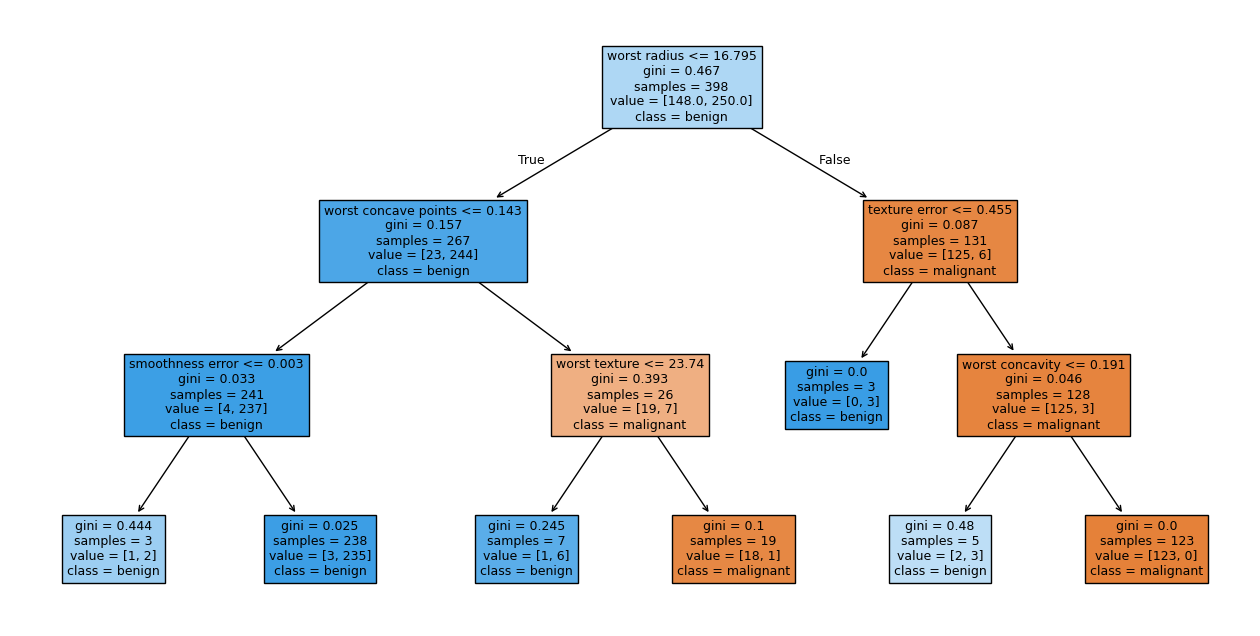

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3
)
plt.show()


## Step 7: Inspecting leaf behaviour

For a decision tree, we are able to trace back to find the ID of the leaf node each sample ends up in.

In other words:
Each row in X_test is passed down the trained tree, we are able to trace it to find out the leaf it ends up with using apply().


So the result tells us how many test samples end up in each leaf node.

In [ ]:
leaf_ids = model.apply(X_test)
pd.Series(leaf_ids).value_counts()

,count
4,54
12,25
7,3
3,2
11,1
9,1


Leaves with many samples means high support leaves.

Leaves with very few samples means low support leaves / very specific rules.

Many tiny leaves are a sign of:
- overfitting
- memorisation

Typically
Shallow trees has fewer leaves with many samples per leaf
Deep trees has many leaves with fewer samples per leaf

In [ ]:
leaf_counts = pd.Series(leaf_ids).value_counts()
low_support_leaves = leaf_counts[leaf_counts < 5].index
low_support_leaves

Index([7, 3, 11, 9], dtype='int64')

In [ ]:
low_support_mask = pd.Series(
    leaf_ids,
    index=X_test.index
).isin(low_support_leaves)

X_test_low_support = X_test[low_support_mask]
y_test_low_support = y_test[low_support_mask]

In [ ]:
X_test_low_support

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,18.130,25.45,117.20,1009.0,0.13380,0.16790,0.1663,0.09123,0.2394,0.06469
194,14.86,23.21,100.40,671.4,0.10440,0.19800,0.16970,0.08878,0.1737,0.06672,...,16.080,27.78,118.60,784.7,0.13160,0.46480,0.4589,0.17270,0.3000,0.08701
192,9.72,18.22,60.73,288.1,0.06950,0.02344,0.00000,0.00000,0.1653,0.06447,...,9.968,20.83,62.25,303.8,0.07117,0.02729,0.0000,0.00000,0.1909,0.06559
484,15.73,11.28,102.80,747.2,0.10430,0.12990,0.11910,0.06211,0.1784,0.06259,...,17.010,14.20,112.50,854.3,0.15410,0.29790,0.4004,0.14520,0.2557,0.08181
483,13.70,17.64,87.76,571.1,0.09950,0.07957,0.04548,0.03160,0.1732,0.06088,...,14.960,23.53,95.78,686.5,0.11990,0.13460,0.1742,0.09077,0.2518,0.06960
291,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.04819,0.1879,0.05852,...,16.250,26.19,109.10,809.8,0.13130,0.30300,0.1804,0.14890,0.2962,0.08472
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.010,32.94,106.00,788.0,0.17940,0.39660,0.3381,0.15210,0.3651,0.11830


## Final Conceptual Exercise: Applying the Workflow to the Wine Dataset

The Wine dataset contains chemical measurements of wine samples:
- alcohol
- malic acid
- ash
- alcalinity of ash
- magnesium
- total phenols
- flavanoids
- nonflavanoid phenols
- proanthocyanins
- color intensity
- hue
- OD280/OD315 of diluted wines
- proline

Target variable:
- wine class (3 classes)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

### Task 1: Understanding the dataset

Is this a classification or regression problem?

How many features does X have?

Is the target variable categorical or continuous?

In [ ]:
iris = load_wine(as_frame=True)

X = iris.data
y = iris.target

print("Task 1: Dataset basics")
print("Problem type: Classification (target is species classes)")
print("X shape:", X.shape)
print("Number of features:", X.shape[1])
print("Feature names:", list(X.columns))
print("y unique classes:", sorted(y.unique()))
print("y class distribution:\n", y.value_counts())
print()

Task 1: Dataset basics
Problem type: Classification (target is species classes)
X shape: (178, 13)
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
y unique classes: [np.int64(0), np.int64(1), np.int64(2)]
y class distribution:
 target
1    71
0    59
2    48
Name: count, dtype: int64



### Task 2: Data splitting strategy

Split the data into train / validation / test with random_state and stratification?

In [ ]:
# Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Task 2: Split sizes")
print("Train:", X_train.shape, len(y_train))
print("Val:  ", X_val.shape, len(y_val))
print("Test: ", X_test.shape, len(y_test))
print()

print("Class proportions (original):")
print(y.value_counts(normalize=True).sort_index())
print("\nClass proportions (train/val/test):")
print("Train:\n", y_train.value_counts(normalize=True).sort_index())
print("Val:\n", y_val.value_counts(normalize=True).sort_index())
print("Test:\n", y_test.value_counts(normalize=True).sort_index())
print()

Task 2: Split sizes
Train: (124, 13) 124
Val:   (27, 13) 27
Test:  (27, 13) 27

Class proportions (original):
target
0    0.331461
1    0.398876
2    0.269663
Name: proportion, dtype: float64

Class proportions (train/val/test):
Train:
 target
0    0.330645
1    0.403226
2    0.266129
Name: proportion, dtype: float64
Val:
 target
0    0.333333
1    0.370370
2    0.296296
Name: proportion, dtype: float64
Test:
 target
0    0.333333
1    0.407407
2    0.259259
Name: proportion, dtype: float64



### Task 3: Model initialisation and training

You plan to train a Decision Tree classifier.

In [ ]:
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

y_val_pred = dt_baseline.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print("Task 3: Baseline model")
print("Baseline validation accuracy:", val_acc)
print()

Task 3: Baseline model
Baseline validation accuracy: 0.9629629629629629



### Task 4: Model complexity

You experiment with different values of max_depth. Evaluate the model for every value of max_depth to determine how it changes the accuracy.

In [ ]:
depths = [1, 2, 3, 4, 5, 8, 10, None]

rows = []
models_by_depth = {}

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    val_acc = model.score(X_val, y_val)

    rows.append({"max_depth": d, "train_accuracy": train_acc, "val_accuracy": val_acc})
    models_by_depth[d] = model

results = pd.DataFrame(rows).sort_values(
    by=["val_accuracy", "train_accuracy"], ascending=False
).reset_index(drop=True)

print("Task 4: Accuracy vs max_depth (sorted by best val accuracy)")
print(results)
print()

# Pick the best depth by validation accuracy (tie-breaker: simpler depth if you want)
best_depth = results.loc[0, "max_depth"]
best_model = models_by_depth[best_depth]

print("Best max_depth by validation accuracy:", best_depth)
print("Best model Train acc:", best_model.score(X_train, y_train))
print("Best model Val acc:  ", best_model.score(X_val, y_val))
print()

# Evaluate best model once on test set (final)
test_acc = best_model.score(X_test, y_test)
print("Final (one-time) Test accuracy of best model:", test_acc)
print()

Task 4: Accuracy vs max_depth (sorted by best val accuracy)
   max_depth  train_accuracy  val_accuracy
0        4.0        1.000000      0.962963
1        5.0        1.000000      0.962963
2        8.0        1.000000      0.962963
3       10.0        1.000000      0.962963
4        NaN        1.000000      0.962963
5        3.0        0.991935      0.962963
6        2.0        0.935484      0.851852
7        1.0        0.661290      0.555556

Best max_depth by validation accuracy: 4.0
Best model Train acc: 1.0
Best model Val acc:   0.9629629629629629

Final (one-time) Test accuracy of best model: 0.9629629629629629



### Task 5: Feature importance

For each value of max_depth, the tree produces a set of feature importance scores. See how it changes with max_depth.

In [ ]:
fi_table = pd.DataFrame(index=X.columns)

for d in depths:
    model = models_by_depth[d]
    fi_table[f"depth={d}"] = model.feature_importances_

fi_table

,depth=1,depth=2,depth=3,depth=4,depth=5,depth=8,depth=10,depth=None
alcohol,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
malic_acid,0.0,0.000000,0.000000,0.021034,0.021034,0.021034,0.021034,0.021034
ash,0.0,0.027791,0.023409,0.022916,0.022916,0.022916,0.022916,0.022916
alcalinity_of_ash,0.0,0.000000,0.024330,0.023818,0.023818,0.023818,0.023818,0.023818
magnesium,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
total_phenols,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
flavanoids,0.0,0.491049,0.413615,0.404915,0.404915,0.404915,0.404915,0.404915
nonflavanoid_phenols,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
proanthocyanins,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
color_intensity,1.0,0.481160,0.405286,0.396761,0.396761,0.396761,0.396761,0.396761


In [ ]:
best_depth = 4
sort_col = f"depth={best_depth}"
fi_table_sorted = fi_table.sort_values(by=sort_col, ascending=False)

print("Task 5: Feature importance by depth (rows=features)")
print(fi_table_sorted)

Task 5: Feature importance by depth (rows=features)
                              depth=1   depth=2   depth=3   depth=4   depth=5  \
flavanoids                        0.0  0.491049  0.413615  0.404915  0.404915   
color_intensity                   1.0  0.481160  0.405286  0.396761  0.396761   
proline                           0.0  0.000000  0.108863  0.106573  0.106573   
od280/od315_of_diluted_wines      0.0  0.000000  0.024497  0.023982  0.023982   
alcalinity_of_ash                 0.0  0.000000  0.024330  0.023818  0.023818   
ash                               0.0  0.027791  0.023409  0.022916  0.022916   
malic_acid                        0.0  0.000000  0.000000  0.021034  0.021034   
magnesium                         0.0  0.000000  0.000000  0.000000  0.000000   
alcohol                           0.0  0.000000  0.000000  0.000000  0.000000   
proanthocyanins                   0.0  0.000000  0.000000  0.000000  0.000000   
nonflavanoid_phenols              0.0  0.000000  0.000000

In [ ]:
top_features_rows = []

for d in depths:
    col = f"depth={d}"
    top3 = fi_table[col].sort_values(ascending=False).head(3)
    top_features_rows.append({
        "max_depth": d,
        "top_feature_1": top3.index[0],
        "top_feature_2": top3.index[1],
        "top_feature_3": top3.index[2],
    })

top_features_df = pd.DataFrame(top_features_rows)

print("Top 3 features by max_depth:")
print(top_features_df)


Top 3 features by max_depth:
   max_depth    top_feature_1    top_feature_2 top_feature_3
0        1.0  color_intensity       malic_acid           ash
1        2.0       flavanoids  color_intensity           ash
2        3.0       flavanoids  color_intensity       proline
3        4.0       flavanoids  color_intensity       proline
4        5.0       flavanoids  color_intensity       proline
5        8.0       flavanoids  color_intensity       proline
6       10.0       flavanoids  color_intensity       proline
7        NaN       flavanoids  color_intensity       proline
